## Business Context:

An automobile parts manufacturing company has been actively selling products to a diverse range of customers for the past three years. Despite its growth, the company lacks the in-house expertise to derive actionable insights from its transaction data. As a result, they wish to uncover hidden patterns and trends in their customer transactions. By analyzing this data, the company aims to better understand customer behavior, improve customer segmentation, and implement targeted marketing strategies. These insights will help the company not only enhance customer satisfaction but also drive revenue growth by offering more personalized and efficient services.

## Objective:
The primary objective of this analysis is to leverage data science techniques to:

Identify underlying patterns in customer purchasing behavior.
Segment customers based on their transactional data.
Provide actionable insights to optimize the company's marketing efforts.
Recommend personalized marketing strategies for each customer segment to maximize sales and customer retention.

**Importing the necessary libraries**

In [1]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np
from datetime import datetime

# To suppress scientific notations
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# To supress warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
Data = pd.read_excel('Sales_Data.xlsx')

In [3]:
# copying data to another variable to avoid any changes to original data
data = Data.copy()

## **Data Overview**

In [4]:
data.head(10)

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,DAYS_SINCE_LASTORDER,STATUS,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,PHONE,ADDRESSLINE1,CITY,POSTALCODE,COUNTRY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.700,2,2871.000,2018-02-24,828,Shipped,Motorcycles,95,S10_1678,Land of Toys Inc.,2125557818,897 Long Airport Avenue,NYC,10022,USA,Yu,Kwai,Small
1,10121,34,81.350,5,2765.900,2018-05-07,757,Shipped,Motorcycles,95,S10_1678,Reims Collectables,26.47.1555,59 rue de l'Abbaye,Reims,51100,France,Henriot,Paul,Small
2,10134,41,94.740,2,3884.340,2018-07-01,703,Shipped,Motorcycles,95,S10_1678,Lyon Souveniers,+33 1 46 62 7555,27 rue du Colonel Pierre Avia,Paris,75508,France,Da Cunha,Daniel,Medium
3,10145,45,83.260,6,3746.700,2018-08-25,649,Shipped,Motorcycles,95,S10_1678,Toys4GrownUps.com,6265557265,78934 Hillside Dr.,Pasadena,90003,USA,Young,Julie,Medium
4,10168,36,96.660,1,3479.760,2018-10-28,586,Shipped,Motorcycles,95,S10_1678,Technics Stores Inc.,6505556809,9408 Furth Circle,Burlingame,94217,USA,Hirano,Juri,Medium
5,10180,29,86.130,9,2497.770,2018-11-11,573,Shipped,Motorcycles,95,S10_1678,Daedalus Designs Imports,20.16.1555,"184, chausse de Tournai",Lille,59000,France,Rance,Martine,Small
6,10188,48,114.840,1,5512.320,2018-11-18,567,Shipped,Motorcycles,95,S10_1678,Herkku Gifts,+47 2267 3215,"Drammen 121, PR 744 Sentrum",Bergen,N 5804,Norway,Oeztan,Veysel,Medium
7,10211,41,114.840,14,4708.440,2019-01-15,510,Shipped,Motorcycles,95,S10_1678,Auto Canal Petit,(1) 47.55.6555,"25, rue Lauriston",Paris,75016,France,Perrier,Dominique,Medium
8,10223,37,107.180,1,3965.660,2019-02-20,475,Shipped,Motorcycles,95,S10_1678,"Australian Collectors, Co.",03 9520 4555,636 St Kilda Road,Melbourne,3004,Australia,Ferguson,Peter,Medium
9,10237,23,101.440,7,2333.120,2019-04-05,432,Shipped,Motorcycles,95,S10_1678,Vitachrome Inc.,2125551500,2678 Kingston Rd.,NYC,10022,USA,Frick,Michael,Small


In [5]:
data.tail()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,DAYS_SINCE_LASTORDER,STATUS,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,PHONE,ADDRESSLINE1,CITY,POSTALCODE,COUNTRY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
2742,10350,20,112.220,15,2244.400,2019-12-02,2924,Shipped,Ships,54,S72_3212,Euro Shopping Channel,(91) 555 94 44,"C/ Moralzarzal, 86",Madrid,28034,Spain,Freyre,Diego,Small
2743,10373,29,137.190,1,3978.510,2020-01-31,2865,Shipped,Ships,54,S72_3212,"Oulu Toy Supplies, Inc.",981-443655,Torikatu 38,Oulu,90110,Finland,Koskitalo,Pirkko,Medium
2744,10386,43,125.990,4,5417.570,2020-03-01,2836,Resolved,Ships,54,S72_3212,Euro Shopping Channel,(91) 555 94 44,"C/ Moralzarzal, 86",Madrid,28034,Spain,Freyre,Diego,Medium
2745,10397,34,62.240,1,2116.160,2020-03-28,2810,Shipped,Ships,54,S72_3212,Alpha Cognac,61.77.6555,1 rue Alsace-Lorraine,Toulouse,31000,France,Roulet,Annette,Small
2746,10414,47,65.520,9,3079.440,2020-05-06,2772,On Hold,Ships,54,S72_3212,Gifts4AllAges.com,6175559555,8616 Spinnaker Dr.,Boston,51003,USA,Yoshido,Juri,Medium


In [6]:
data.shape

(2747, 20)

 #### The dataset has 2747 rows and 20 columns.

### Checking the data types of the columns for the dataset.

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2747 entries, 0 to 2746
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ORDERNUMBER           2747 non-null   int64         
 1   QUANTITYORDERED       2747 non-null   int64         
 2   PRICEEACH             2747 non-null   float64       
 3   ORDERLINENUMBER       2747 non-null   int64         
 4   SALES                 2747 non-null   float64       
 5   ORDERDATE             2747 non-null   datetime64[ns]
 6   DAYS_SINCE_LASTORDER  2747 non-null   int64         
 7   STATUS                2747 non-null   object        
 8   PRODUCTLINE           2747 non-null   object        
 9   MSRP                  2747 non-null   int64         
 10  PRODUCTCODE           2747 non-null   object        
 11  CUSTOMERNAME          2747 non-null   object        
 12  PHONE                 2747 non-null   object        
 13  ADDRESSLINE1      

### Checking for missing values

In [8]:
# checking for null values
data.isnull().sum()

ORDERNUMBER             0
QUANTITYORDERED         0
PRICEEACH               0
ORDERLINENUMBER         0
SALES                   0
ORDERDATE               0
DAYS_SINCE_LASTORDER    0
STATUS                  0
PRODUCTLINE             0
MSRP                    0
PRODUCTCODE             0
CUSTOMERNAME            0
PHONE                   0
ADDRESSLINE1            0
CITY                    0
POSTALCODE              0
COUNTRY                 0
CONTACTLASTNAME         0
CONTACTFIRSTNAME        0
DEALSIZE                0
dtype: int64

* There are no null values in the dataset

## Checking for Duplicates

In [9]:
data.duplicated().sum()

0

* No duplicates in the dataset.

In [10]:
data.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
ORDERNUMBER,2747.000,NaN,NaN,NaN,10259.762,10100.000,10181.000,10264.000,10334.500,10425.000,91.878
QUANTITYORDERED,2747.000,NaN,NaN,NaN,35.103,6.000,27.000,35.000,43.000,97.000,9.762
PRICEEACH,2747.000,NaN,NaN,NaN,101.099,26.880,68.745,95.550,127.100,252.870,42.043
ORDERLINENUMBER,2747.000,NaN,NaN,NaN,6.491,1.000,3.000,6.000,9.000,18.000,4.231
SALES,2747.000,NaN,NaN,NaN,3553.048,482.130,2204.350,3184.800,4503.095,14082.800,1838.954
ORDERDATE,2747,NaN,NaN,NaN,2019-05-13 21:56:17.211503360,2018-01-06 00:00:00,2018-11-08 00:00:00,2019-06-24 00:00:00,2019-11-17 00:00:00,2020-05-31 00:00:00,NaN
DAYS_SINCE_LASTORDER,2747.000,NaN,NaN,NaN,1757.086,42.000,1077.000,1761.000,2436.500,3562.000,819.281
STATUS,2747,6,Shipped,2541,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PRODUCTLINE,2747,7,Classic Cars,949,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MSRP,2747.000,NaN,NaN,NaN,100.692,33.000,68.000,99.000,124.000,214.000,40.115


## Exploratory Data Analysis

#### The below functions need to be defined to carry out the Exploratory Data Analysis.

In [11]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [12]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [13]:
# function to plot stacked bar chart

def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 1, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [14]:
### Function to plot distributions

def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

### Univariate analysis

`QUANTITYORDERED`

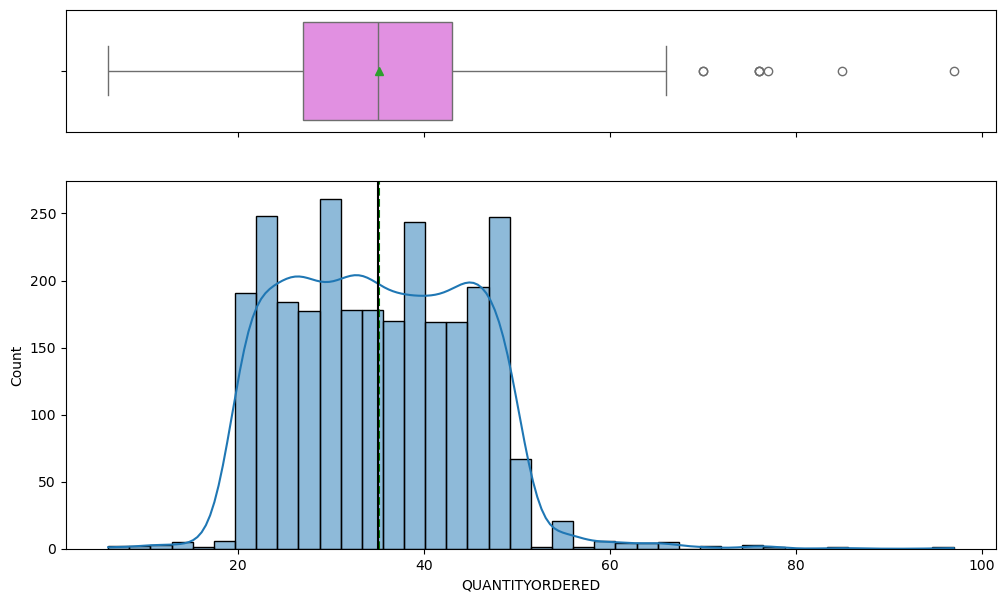

In [15]:
histogram_boxplot(data, "QUANTITYORDERED", kde=True)

The distribution of the QUANTITYORDERED is slightly skewed to the right, meaning most orders have a median order quantity of 36, 75% of data has order quantity of below 70.
There are few outliers in the dataset.

`PRICEEACH`

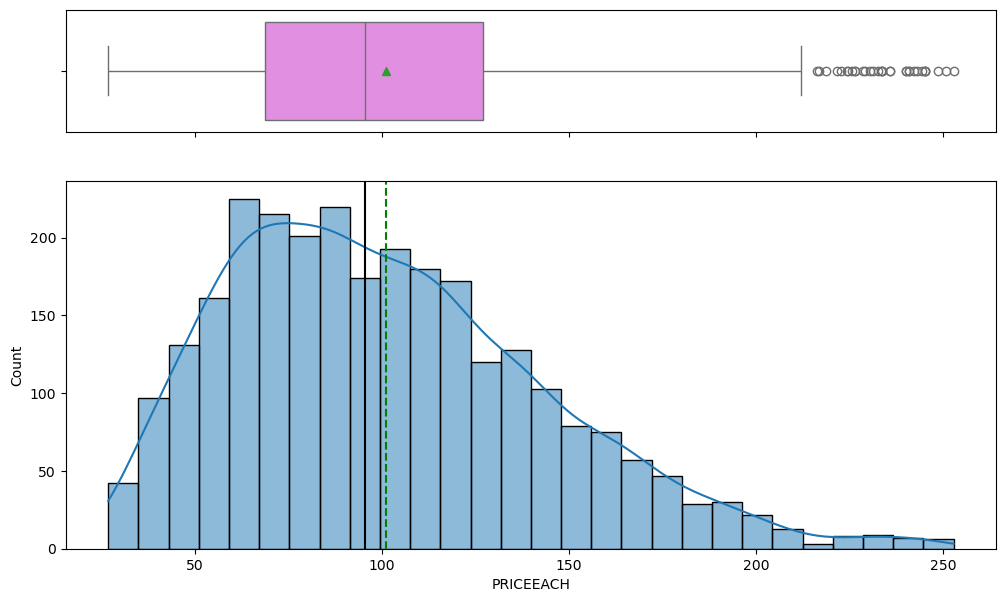

In [16]:
histogram_boxplot(data, "PRICEEACH", kde=True)

The distribution of the PRICEEACH is slightly skewed to the right, meaning most orders have a median Prrice per unit of ~100, 50% of data has price of below 100. There are outliers in the dataset.

`ORDERLINENUMBER`

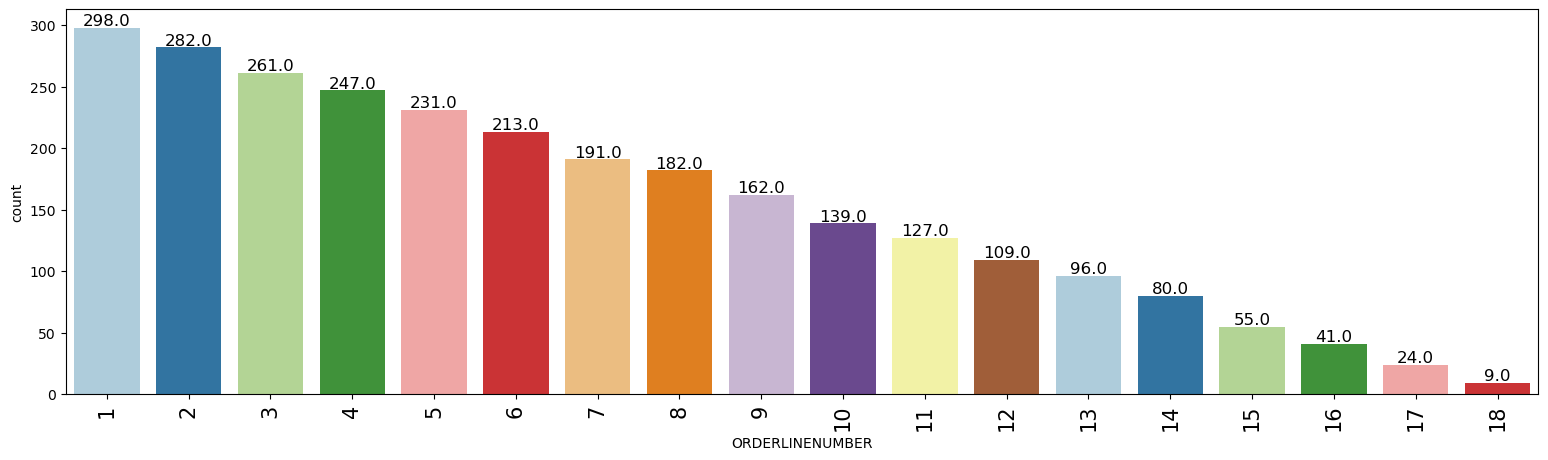

In [17]:
labeled_barplot(data, "ORDERLINENUMBER")

`SALES`

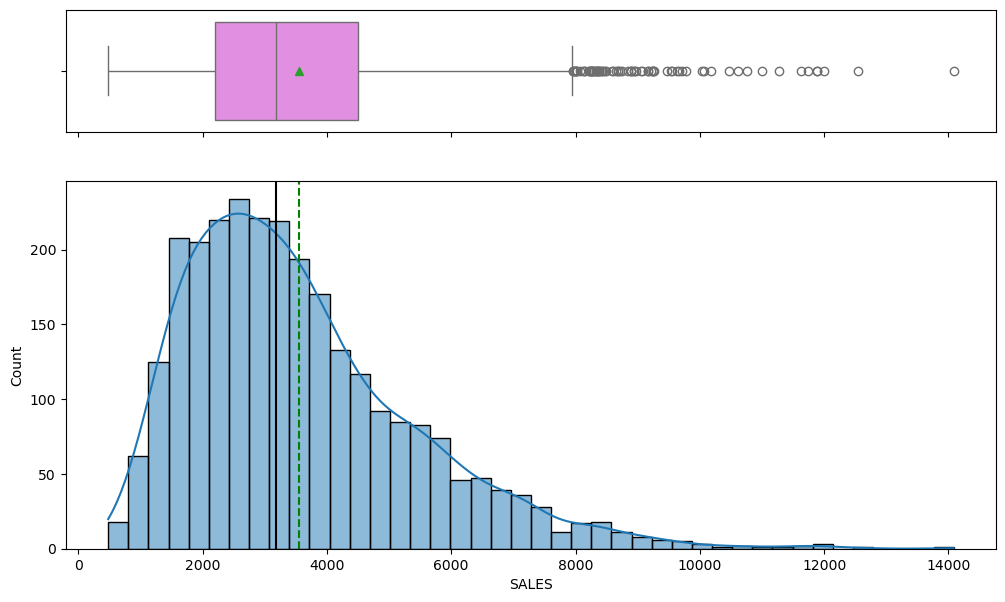

In [18]:
histogram_boxplot(data, "SALES", kde=True)

`ORDERDATE`

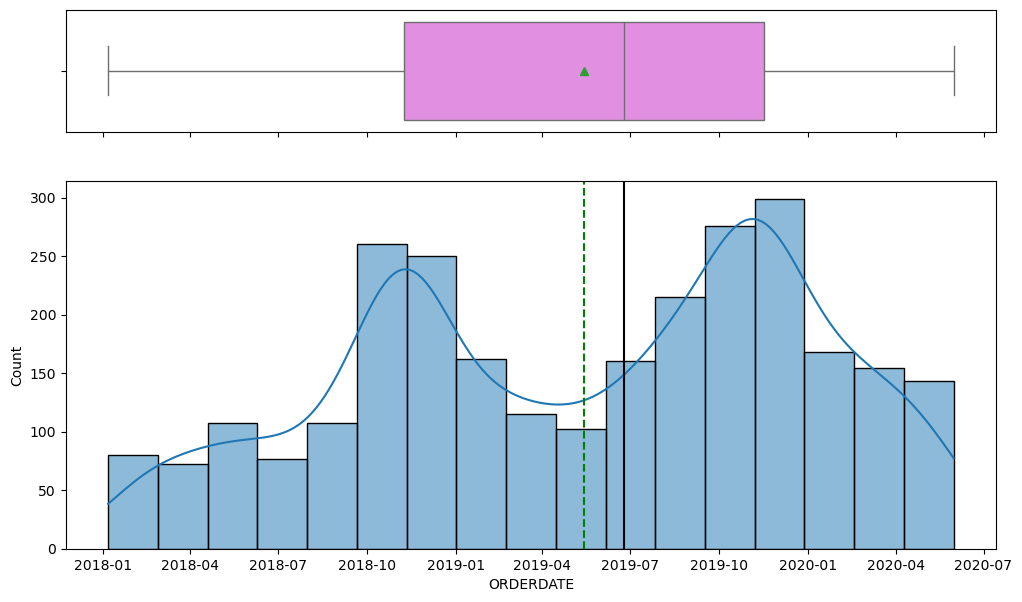

In [19]:
histogram_boxplot(data, "ORDERDATE", kde=True)

`DAYS_SINCE_LASTORDER`

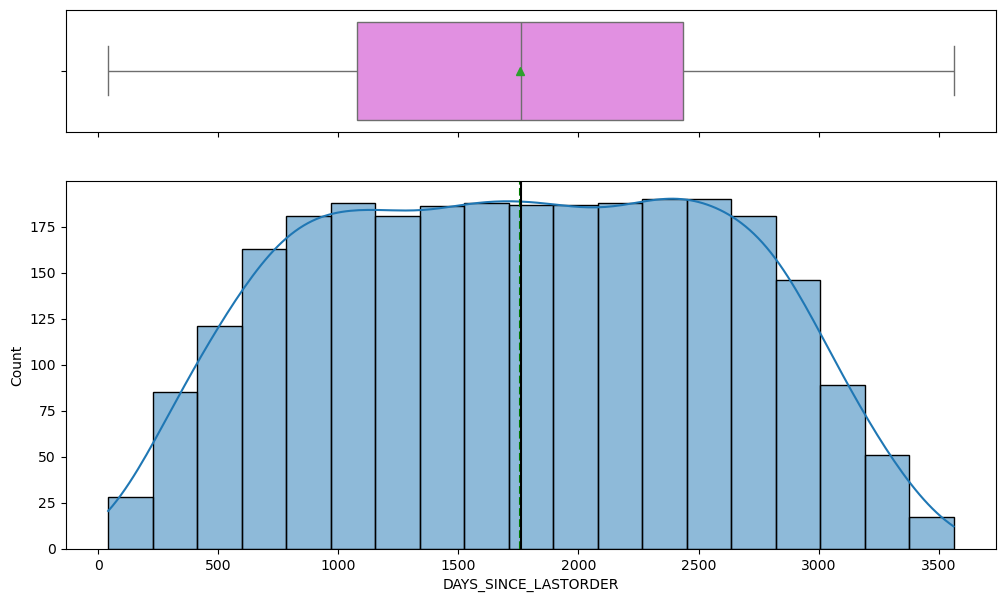

In [20]:
histogram_boxplot(data, "DAYS_SINCE_LASTORDER", kde=True)

`STATUS`

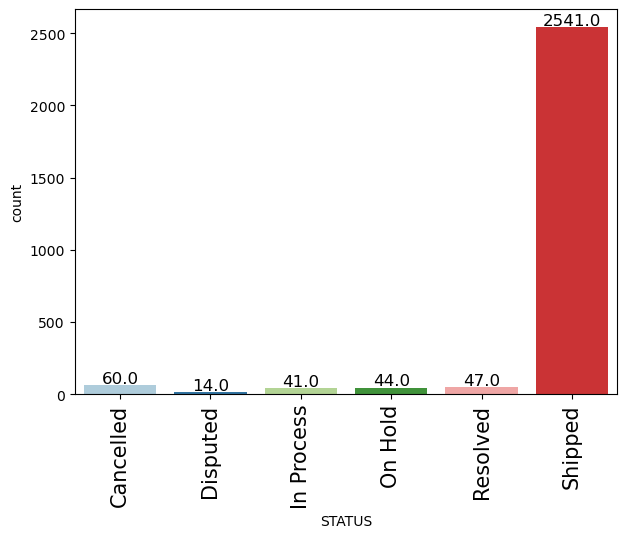

In [21]:
labeled_barplot(data, "STATUS")

`PRODUCTLINE`

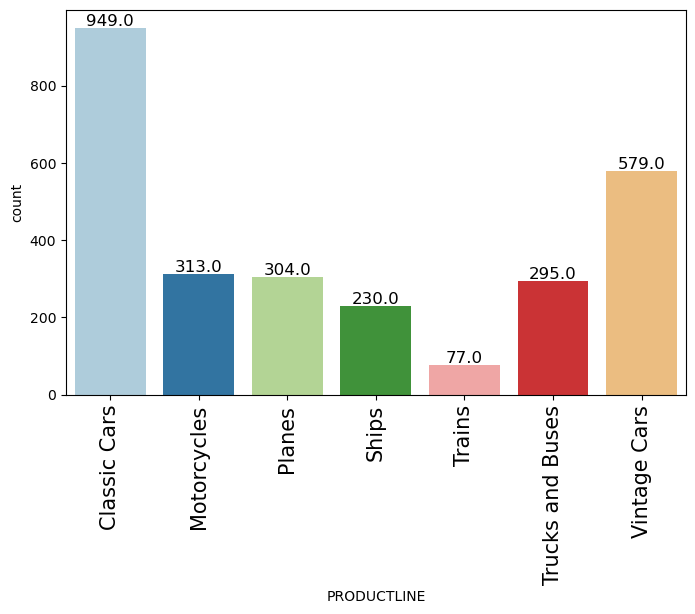

In [22]:
labeled_barplot(data, "PRODUCTLINE")

`MSRP`

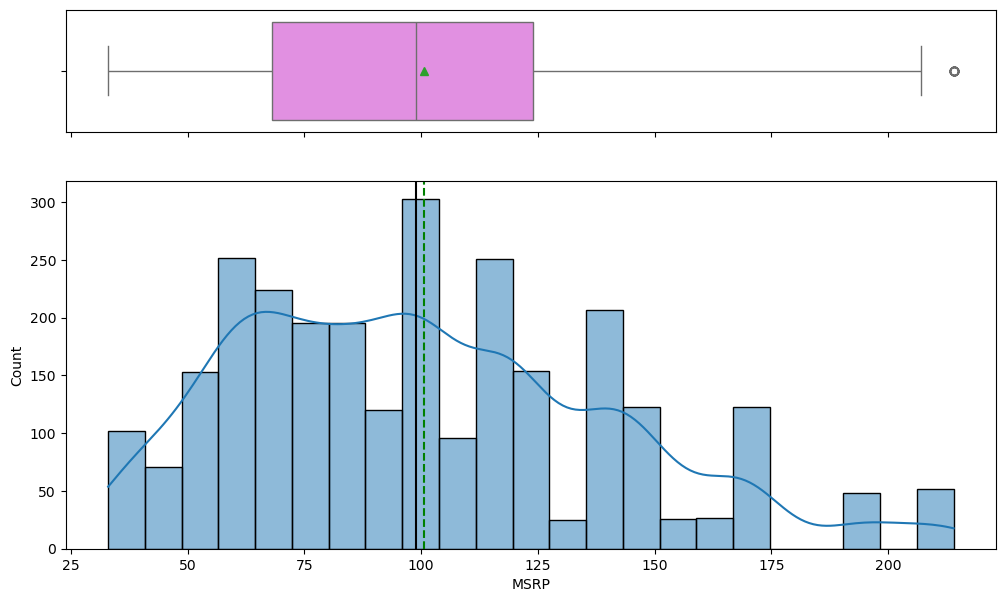

In [23]:
histogram_boxplot(data, "MSRP", kde=True)

`PRODUCTCODE`

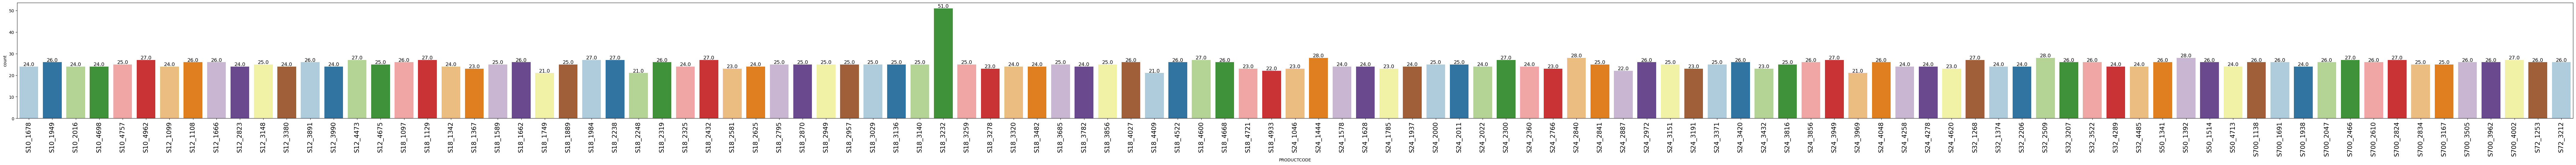

In [24]:
labeled_barplot(data, "PRODUCTCODE")

`PRODUCTCODE`

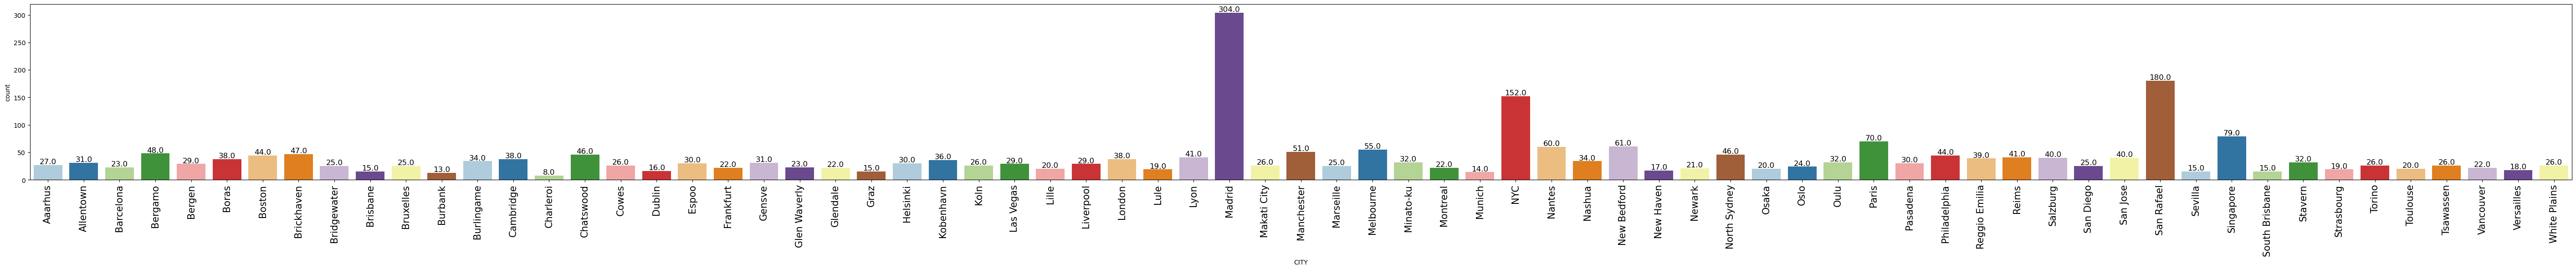

In [25]:
labeled_barplot(data, "CITY")

`COUNTRY`

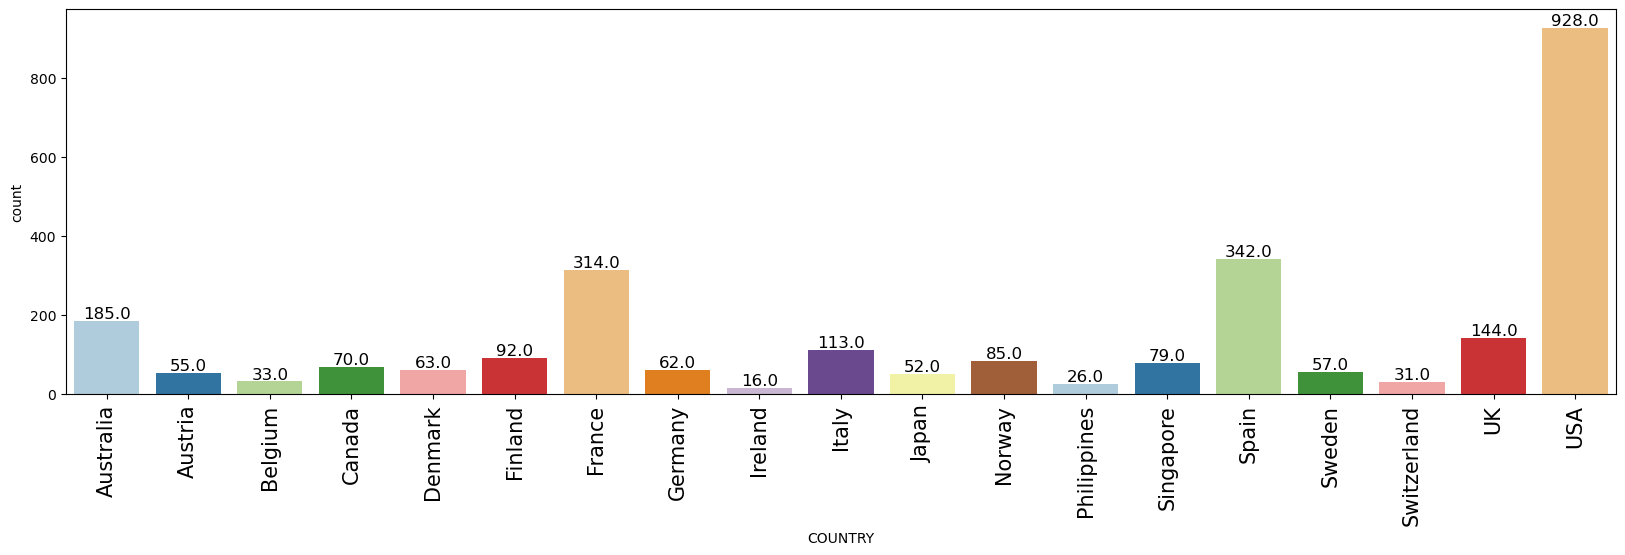

In [26]:
labeled_barplot(data, "COUNTRY")

`DEALSIZE`

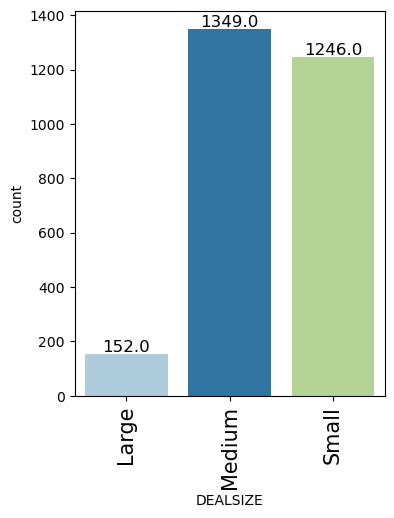

In [27]:
labeled_barplot(data, "DEALSIZE")

### Bivariate analysis

**Correlation Check**

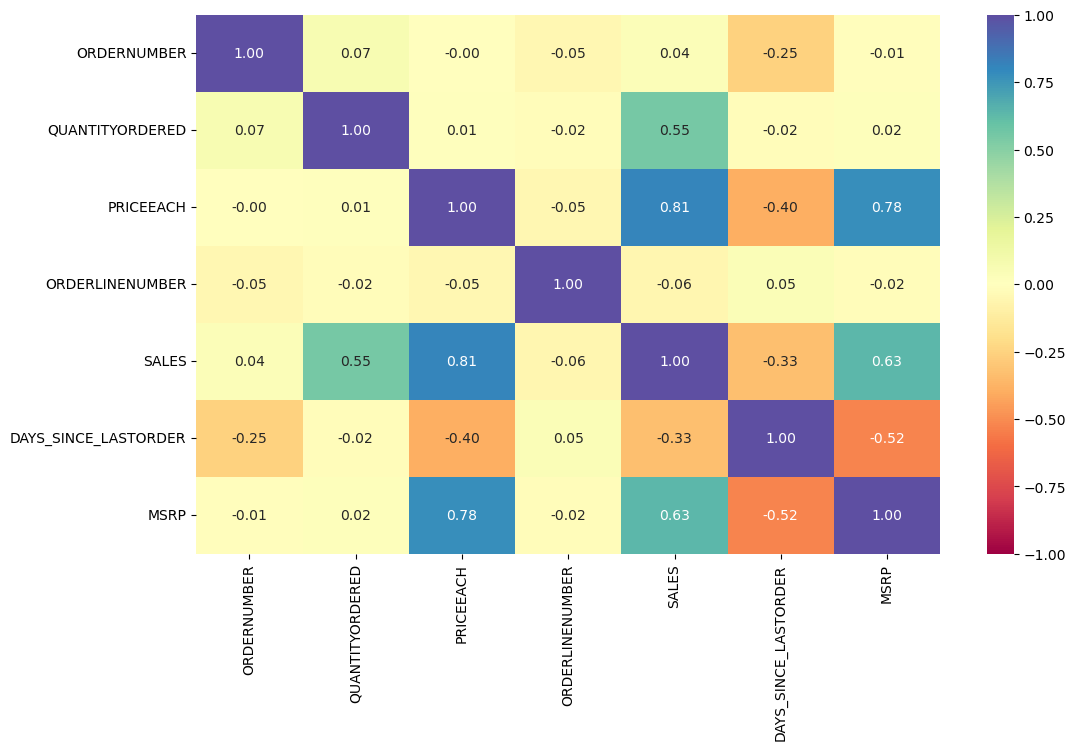

In [28]:
cols_list = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(12, 7))
sns.heatmap(
    data[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

**Sales & Quantity Ordered:** these two variables have a strong positive correlation, it suggests that bulk orders significantly contribute to revenue.

**DAYS_SINCE_LASTORDER & SALES:** there’s a noticeable negative correlation, frequent buyers tend to generate higher sales.

**PRICEEACH & MSRP:** A high correlation here may indicate consistent pricing strategy.


In [29]:
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()

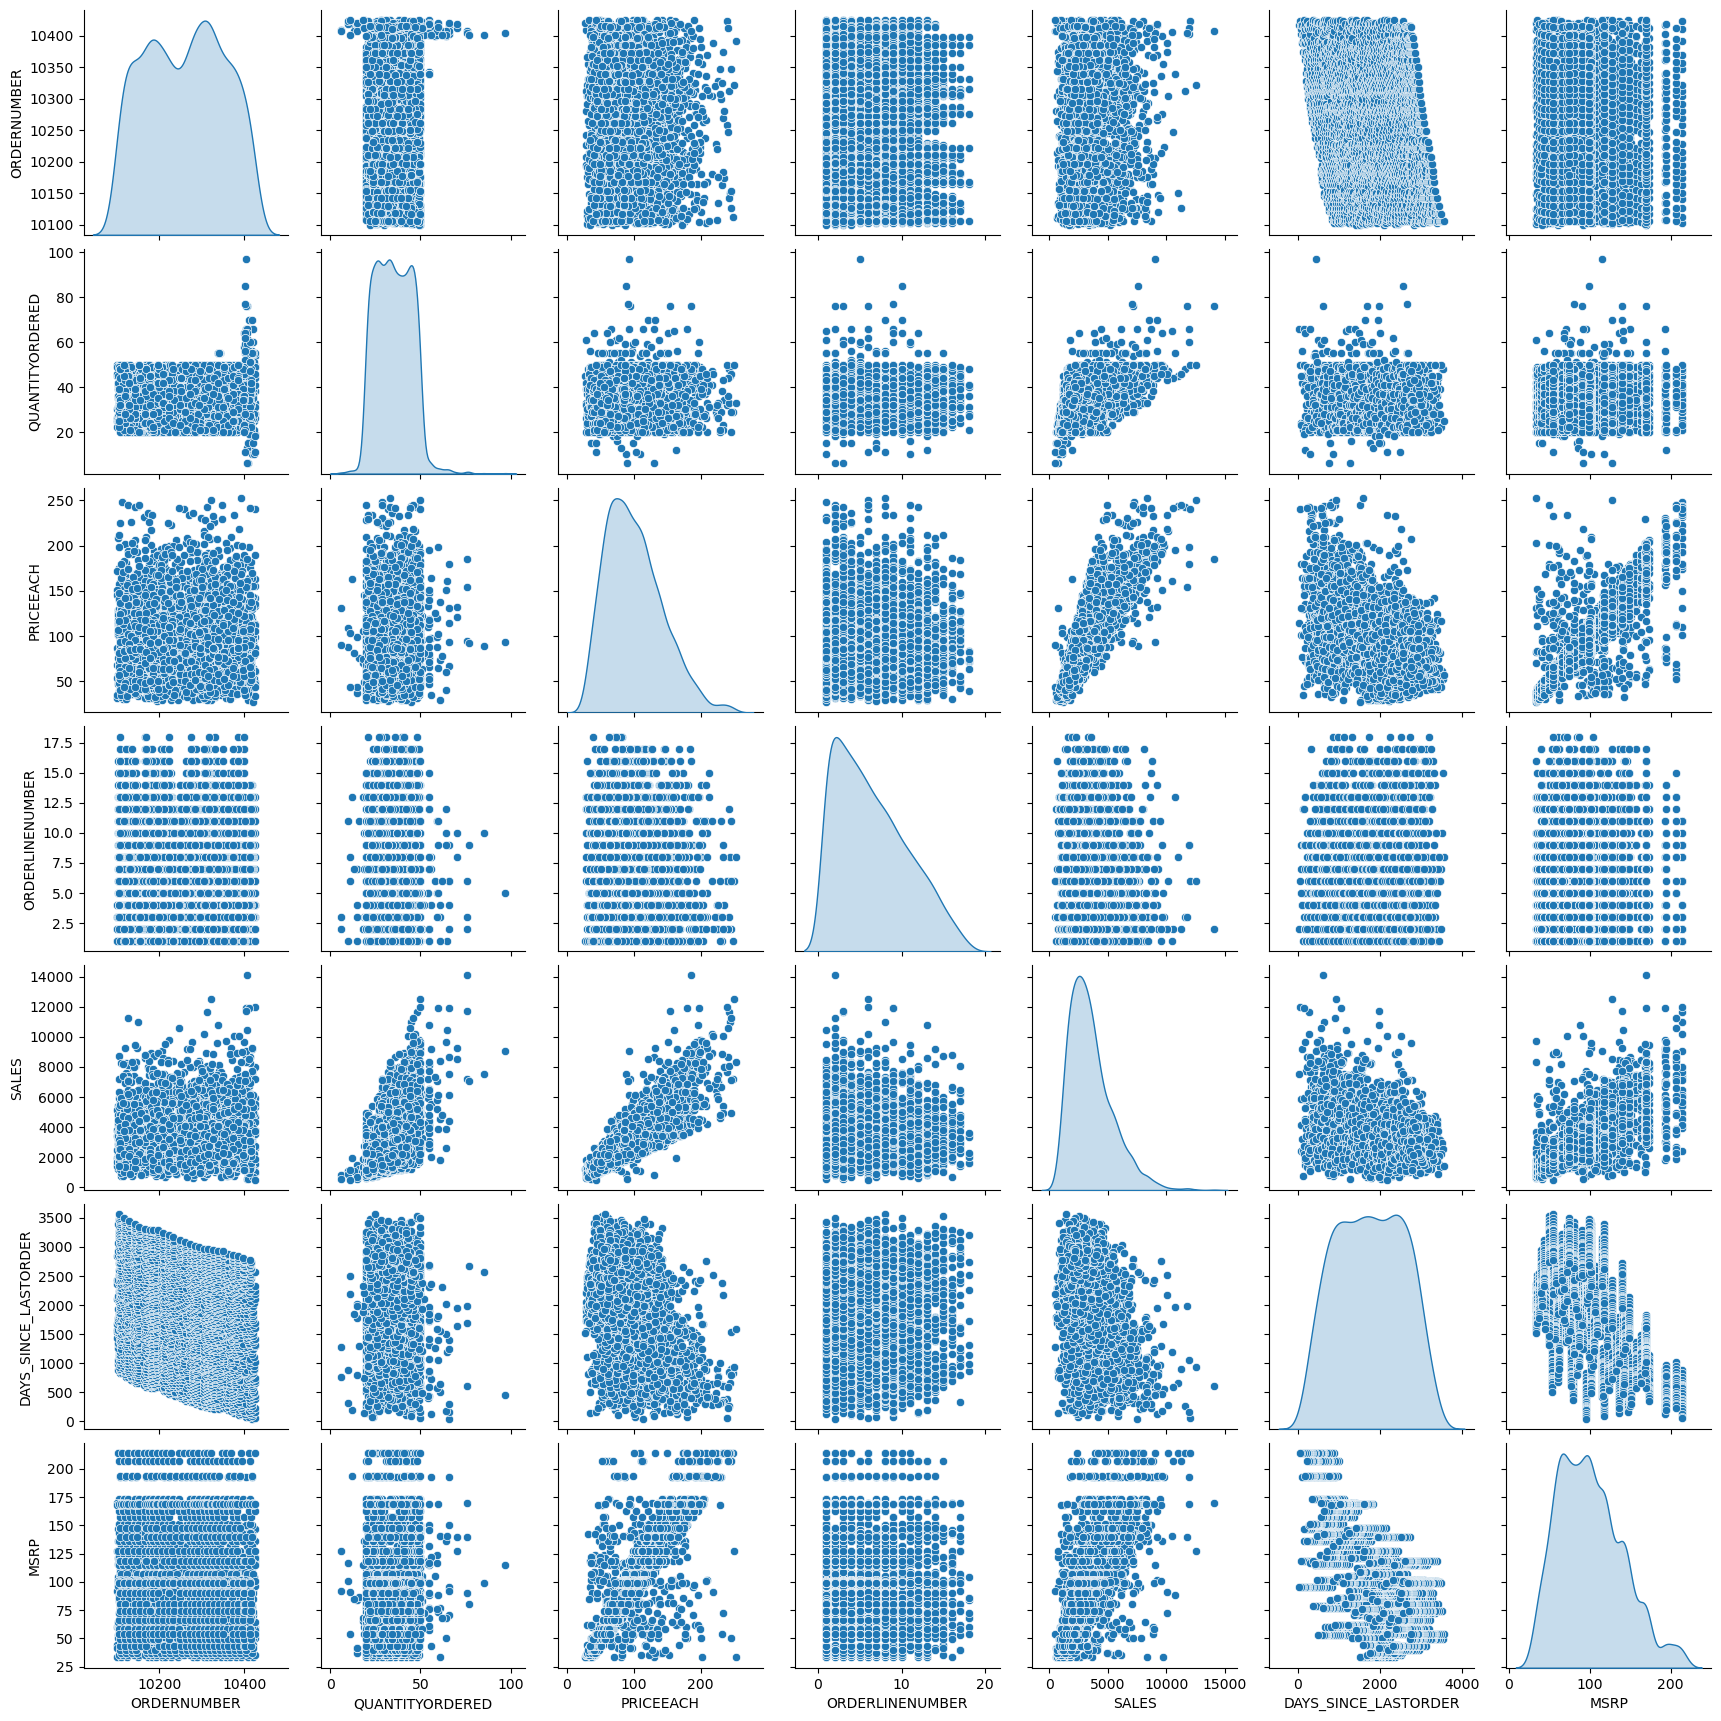

In [30]:
sns.pairplot(data=data[numeric_columns], diag_kind="kde")
plt.show()

* SALES vs. PRICEEACH: A strong positive correlation suggests that higher-priced items tend to generate more revenue.
* SALES vs. MSRP: A similar positive correlation implies that products with a higher MSRP are often sold at a higher price point.
* QUANTITYORDERED vs. SALES: If there’s a noticeable trend where higher quantities lead to higher sales, bulk purchasing might be a key driver.
* DAYS_SINCE_LASTORDER vs. SALES: A weak correlation here might indicate irregular purchasing behaviors, signaling opportunities for retention-focused marketing strategies.
* Some histograms show right-skewed distributions (e.g., PRICEEACH and MSRP) indicating that most transactions involve lower-priced items, but occasional high-value orders skew the data.
